# 距离向量路由 和 链路状态路由

In [24]:
# 导入库 networkx 生成一个图
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal, ROUND_HALF_UP
from copy import deepcopy

In [25]:
class config:
    def __init__(self):
        self.n = 10     # 节点数
        self.mu_edge = 23    # 正态分布均值
        self.std_edge = 2    # 正态分布标准差
        self.mu_weight = 5   # 边权重分布的均值
        self.std_weight = 4  # 边权重分布的标准差
        self.max_edges = 45     # 10个节点的最大可能边数（无向图）

In [26]:
# 设置参数
Config = config()

In [27]:
while True:
    num_edges = int(np.random.normal(Config.mu_edge, Config.std_edge))
    num_edges = max(0, min(num_edges, Config.max_edges))      # 限制边的数量
    if num_edges >= 0:
        break

In [28]:
# 创建随机图
G = nx.gnm_random_graph(Config.n, num_edges)

# 添加正态分布权重（非负）
weights = []
for u, v in G.edges():
    # 生成权重
    while True:
        w = np.random.normal(Config.mu_weight, Config.std_weight)
        if w >= 0:
            break
    
    w = Decimal(w)
    w = float(w.quantize(Decimal('0.00'), rounding=ROUND_HALF_UP))
    G[u][v]['weight'] = w
    weights.append(w)


{(0, 5): Text(0.7505204506370409, -0.2818192563669962, '10.43'),
 (0, 8): Text(0.27666001219259384, 0.05181085395387358, '0.33'),
 (1, 6): Text(-0.43373962103106845, -0.07746410955774385, '5.35'),
 (1, 4): Text(-0.6475151854882656, -0.28280281504466737, '4.49'),
 (1, 8): Text(-0.5446974941903597, 0.18114501941710784, '4.84'),
 (1, 2): Text(-0.205561868181677, -0.3255885797636474, '0.62'),
 (1, 5): Text(-0.0708370557459127, -0.15248509090376192, '1.24'),
 (2, 6): Text(0.0034135235531617403, -0.3196617527529353, '2.54'),
 (2, 9): Text(0.16666001960034446, -0.16329761492788591, '1.72'),
 (2, 5): Text(0.36631608883831746, -0.3946827340989533, '7.74'),
 (3, 6): Text(-0.2010935729551619, 0.3051540150976776, '4.85'),
 (3, 7): Text(0.06605681770640046, 0.5408478399117294, '3.4'),
 (3, 9): Text(-0.03784707690797915, 0.46151815292272697, '1.5'),
 (3, 8): Text(-0.3120514461144532, 0.5637631440725293, '6.62'),
 (4, 6): Text(-0.4385397937534269, -0.2768759880339552, '9.85'),
 (5, 6): Text(0.1381383

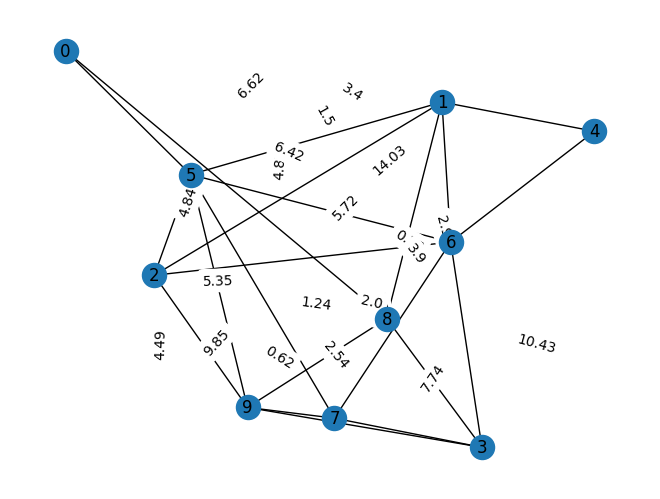

In [29]:
# 节点位置
pos = nx.spring_layout(G)
nx.draw(G, with_labels = True)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

In [30]:
# 结果输出
print(f"生成边数: {G.number_of_edges()}")
print(f"权重均值: {np.mean(weights):.2f} ± {np.std(weights):.2f}")
print(f"最小权重: {np.min(weights):.2f}, 最大权重: {np.max(weights):.2f}")

生成边数: 21
权重均值: 4.79 ± 3.43
最小权重: 0.33, 最大权重: 14.03


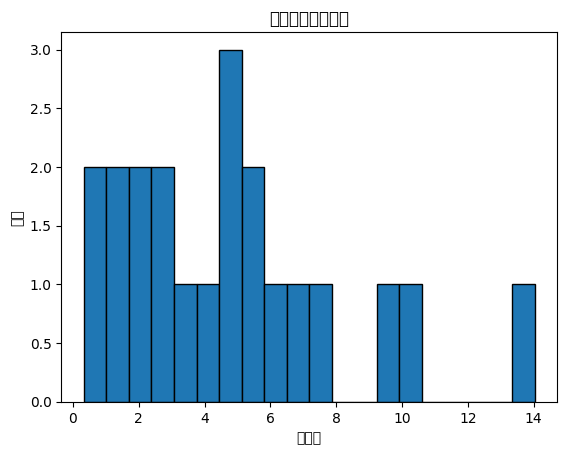

In [31]:
plt.hist(weights, bins=20, edgecolor='black')
plt.title('边权重分布直方图')
plt.xlabel('权重值')
plt.ylabel('频次')
plt.show()

In [32]:
# 距离向量路由
class DistanceVectorRouter:
    def __init__(self, graph):
        self.graph = graph
        self.nodes = list(graph.nodes())
        self.distance_vectors = {node: self._init_distance_vector(node) for node in self.nodes}
        self.converged = False
        self.iteration_count = 0
    
    def _init_distance_vector(self, node):
        """初始化节点的距离向量"""
        dv = {dest: (np.inf, None) for dest in self.nodes}
        dv[node] = (0, node)    # 到自己距离为0
        
        # 初始化邻居
        for neighbor in self.graph.neighbors(node):
            dv[neighbor] = (self.graph[node][neighbor]['weight'], neighbor)
        
        return dv
    
    def _update_node(self, node):
        """节点的距离向量更新"""
        
        updated = False
        current_dv = self.distance_vectors[node].copy()
        
        for neighbor in self.graph.neighbors(node):
            # 获取邻居的距离向量
            neighbor_dv = self.distance_vectors[neighbor]
            # 节点到邻居的距离
            link_cost = self.graph[node][neighbor]['weight']
            
            for dest in self.nodes:
                # 通过邻居到达目标的潜在新距离
                new_cost = link_cost + neighbor_dv[dest][0]
                
                # 如有更优路径
                if new_cost < current_dv[dest][0]:
                    current_dv[dest] = (new_cost, neighbor)
                    updated = True
                    
        self.distance_vectors[node] = current_dv
        return updated
    
    def iterate(self):
        """执行一轮迭代"""
        self.iteration_count += 1
        any_updated = False
        
        # 随机顺序更新节点（更符合真实情况）
        for node in np.random.permutation(self.nodes):
            if self._update_node(node):
                any_updated = True
                
        self.converged = not any_updated
        
    
    def print_routing_table(self, node):
        """打印指定节点的路由表"""
        print(f"\n节点 {node} 的路由表（迭代次数：{self.iteration_count}）：")
        print("{:<8} {:<10} {:<10}".format("目标节点", "最短距离", "下一跳"))
        for dest in self.nodes:
            cost, next_hop = self.distance_vectors[node][dest]
            print(f"{dest:<12} {cost:<14.2f} {next_hop if next_hop is not None else 'None'}")
        
    def visualize_routes(self):
        """可视化最终路由路径"""
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.graph)
        nx.draw_networkx_nodes(self.graph, pos)
        nx.draw_networkx_labels(self.graph, pos)
        
        
        # 绘制所有边
        nx.draw_networkx_edges(self.graph, pos, alpha=0.2)
        
        # 高亮最优路径
        for source in self.nodes:
            for target in self.nodes:
                if source == target:
                    continue
                
                path = []
                current = source
                while current != target:
                    next_hop = self.distance_vectors[current][target][1]
                    if next_hop is None:
                        break
                    path.append((current, next_hop))
                    current = next_hop
                
                if path:
                    nx.draw_networkx_edges(
                        self.graph, pos,
                        edgelist=path,
                        edge_color='r',
                        width=2,
                        alpha=0.7
                    )
        
        plt.title(f"路由路径可视化（收敛于 {self.iteration_count} 次迭代）")
        plt.show()   
    
    def get_convergence_speed(self):
        """获取收敛速度指标"""
        return {
            'iterations': self.iteration_count,
            'message_complexity': self.iteration_count * len(self.graph.edges())
        }
    
    def simulate_link_failure(self, node1, node2):
        """模拟链路故障"""
        
        if self.graph.has_edge(node1, node2):
            self.graph[node1][node2]['weight'] = np.inf
            # 重置相关节点的距离向量
            self.distance_vectors[node1] = self._init_distance_vector(node1)
            self.distance_vectors[node2] = self._init_distance_vector(node2)
            
            self.converged = True
        
        

In [33]:
# 使用生成的图进行测试
router = DistanceVectorRouter(G)

# 执行迭代直到收敛（最多50次防止无限循环）
max_iterations = 50
for _ in range(max_iterations):
    router.iterate()
    if router.converged:
        break

# 打印所有节点的路由表
for node in G.nodes():
    router.print_routing_table(node)


节点 0 的路由表（迭代次数：3）：
目标节点     最短距离       下一跳       
0            0.00           0
1            5.17           8
2            5.79           8
3            6.95           8
4            9.66           8
5            6.41           8
6            8.33           8
7            9.40           8
8            0.33           8
9            6.75           8

节点 1 的路由表（迭代次数：3）：
目标节点     最短距离       下一跳       
0            5.17           8
1            0.00           1
2            0.62           2
3            3.84           2
4            4.49           4
5            1.24           5
6            3.16           2
7            4.23           5
8            4.84           8
9            2.34           2

节点 2 的路由表（迭代次数：3）：
目标节点     最短距离       下一跳       
0            5.79           1
1            0.62           1
2            0.00           2
3            3.22           9
4            5.11           1
5            1.86           1
6            2.54           6
7            4.85           1
8      

C:\Users\SUNX\AppData\Local\Temp\ipykernel_22992\3010208158.py:93: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


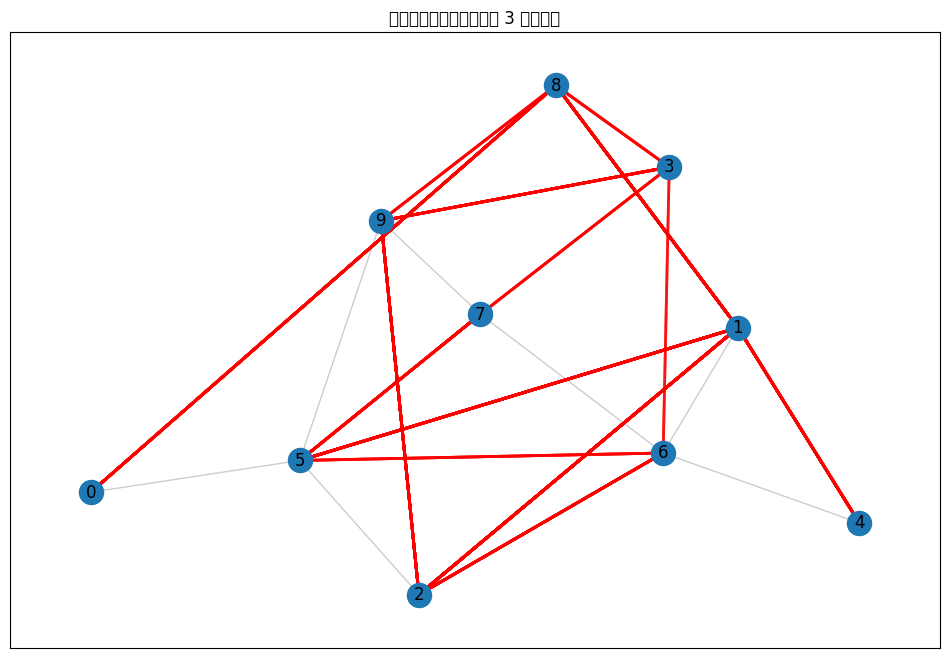


收敛状态: 已收敛
总迭代次数: 3


In [34]:
# 可视化路由路径
router.visualize_routes()

# 输出收敛统计
print(f"\n收敛状态: {'已收敛' if router.converged else '未完全收敛'}")
print(f"总迭代次数: {router.iteration_count}")

In [35]:
# 模拟网络拓扑发现过程
class TopologyDiscovery:
    def __init__(self, graph):
        self.true_graph = graph
        self.node_views = {n: nx.Graph() for n in graph.nodes()}    # 为每个节点设置一个局部视图
        self._init_self_awareness()

    def _init_self_awareness(self):
        """初始化节点只知道自己的信息"""
        for n in self.true_graph.nodes():
            self.node_views[n].add_node(n)

    def propagate_step(self):
        """执行一轮信息传播"""
        new_views = deepcopy(self.node_views)
        for node in self.true_graph.nodes():
            # 向所有邻居发送当前视图
            for neighbor in self.true_graph.neighbors(node):
                # 合并邻居的视图到当前节点
                self.merge_views(new_views[neighbor], self.node_views[node])
                # 添加新的直连边信息
                if not new_views[neighbor].has_edge(node, neighbor):
                    new_views[neighbor].add_edge(node, neighbor,
                                                 weight=self.true_graph[node][neighbor]["weight"])

        self.node_views = new_views

    def merge_views(self, target_view, source_view):
        """合并拓扑信息"""
        target_view.add_nodes_from(source_view.nodes())
        target_view.add_edges_from(source_view.edges(data=True))

    
    def check_convergence(self):
        """检查是否所有节点都知晓完整拓扑"""
        return all(nx.is_isomorphic(view, self.true_graph) 
                   for view in self.node_views.values())
    
    def visualize(self, step):
        """可视化当前状态"""
        
        plt.figure(figsize=(12, 8))
        for i, node in enumerate(sorted(self.node_views.keys())):
            plt.subplot(2, 5, i+1)
            nx.draw(self.node_views[node],
                    with_labels=True,
                    node_color=['red' if n==node else 'skyblue' for n in self.node_views[node].nodes()],
                    edge_camp=plt.cm.Blues,
                    pos=nx.spring_layout(self.true_graph))
            
            plt.title(f"Node {node} View\n({len(self.node_views[node].edges())} edges)")
            
        plt.suptitle(f"Step {step}", fontsize=16)
        plt.tight_layout()
        plt.show()

In [36]:
# 运行模拟
sim = TopologyDiscovery(G)

真实网络拓扑:
节点数: 10
边数: 21


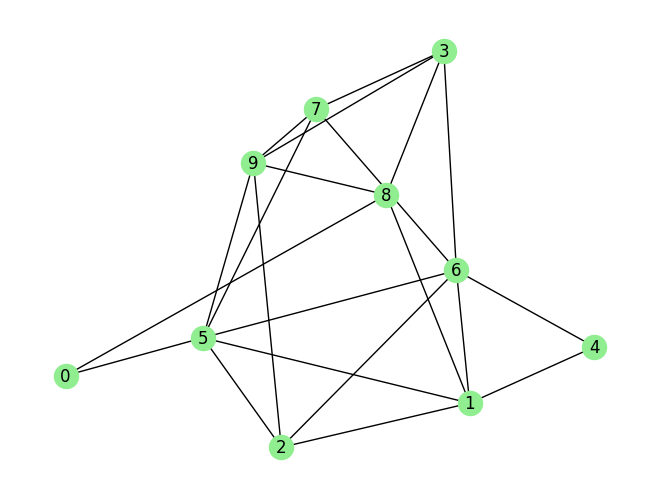

In [37]:
# 输出结果
print("真实网络拓扑:")
print(f"节点数: {G.number_of_nodes()}")
print(f"边数: {G.number_of_edges()}")
nx.draw(G, with_labels=True, node_color='lightgreen')
plt.show()

In [42]:
# 
step = 0
while not sim.check_convergence():
#     sim.visualize(step)
    sim.propagate_step()
    step += 1
    if step > 10:
        break

In [41]:
print(f"在 {step} 步后达到{'完全' if sim.check_convergence() else '部分'}收敛")


在 0 步后达到完全收敛
